# Controlled spherical behavior: weak signal and Geary divergence

This notebook reproduces the two controlled cases from *Spatial
Autocorrelation for Manifold-Valued Geographic Data*. The first places
weakly dispersed observations randomly over an 8-by-8 lattice and checks
that the permutation
probabilities are not forced to their Monte Carlo floor. The second
assigns four spatial blocks to four tangent directions at radius 1.45
radians and shows why the three manifold Geary measures can differ.

Both samples lie inside a spherical ball of radius less than $\pi/2$.
`PAPER_SCALE=True` reproduces the manuscript's 999 permutations; set it
to `False` for a 499-permutation interactive run.

In [1]:
from pathlib import Path
import json
import sys

ROOT = next(
    (
        path
        for path in (Path.cwd(), *Path.cwd().parents)
        if (path / "autocorr.py").is_file() and (path / "data").is_dir()
    ),
    None,
)
if ROOT is None:
    raise FileNotFoundError("Start Jupyter from public/ or public/notebooks/.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import autocorr as ac

ac.set_notebook_style()
paper = json.loads((ROOT / "data" / "paper_scale_summary.json").read_text())
PAPER_SCALE = True
print(f"Public root located. PAPER_SCALE={PAPER_SCALE}")

Public root located. PAPER_SCALE=True


In [2]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

permutations = 999 if PAPER_SCALE else 499
W = ac.rook_weights(8, 8)
north = np.array([0.0, 0.0, 1.0])

rng = np.random.default_rng(100)
null_sample = []
for _ in range(64):
    tangent = np.r_[rng.normal(size=2), 0.0]
    tangent = tangent / np.linalg.norm(tangent) * rng.uniform(0.05, 0.60)
    null_sample.append(ac.sphere_exp(north, tangent))
null_sample = np.asarray(null_sample)
_, null_log, null_d2, null_v = ac.sphere_components(null_sample)
null_result = ac.global_randomization(
    null_log, null_d2, W, V_mu=null_v,
    permutations=permutations, seed=1100,
)

radius = 1.45
directions = np.array([
    [1.0, 0.0, 0.0], [0.0, 1.0, 0.0],
    [-1.0, 0.0, 0.0], [0.0, -1.0, 0.0],
])
regimes = np.empty((8, 8), dtype=int)
high_sample = []
for row in range(8):
    for column in range(8):
        group = 0 if row < 4 and column < 4 else 1 if row < 4 else 2 if column < 4 else 3
        regimes[row, column] = group
        high_sample.append(ac.sphere_exp(north, radius * directions[group]))
high_sample = np.asarray(high_sample)
_, high_log, high_d2, high_v = ac.sphere_components(high_sample)
high_result = ac.global_randomization(
    high_log, high_d2, W, V_mu=high_v,
    permutations=permutations, seed=1200,
)

fresh = pd.DataFrame([
    {"case": "Null-adjacent random field", **null_result.__dict__},
    {"case": "Four spatial regimes", **high_result.__dict__},
])
display(fresh[["case", "I", "p_I_upper", "C_F", "C_P", "C_T", "p_CP_lower"]].round(4))

,case,I,p_I_upper,C_F,C_P,C_T,p_CP_lower
0,Null-adjacent random field,0.0101,0.373,0.9807,0.9926,0.9928,0.483
1,Four spatial regimes,0.7857,0.001,0.1811,0.2299,0.2109,0.001


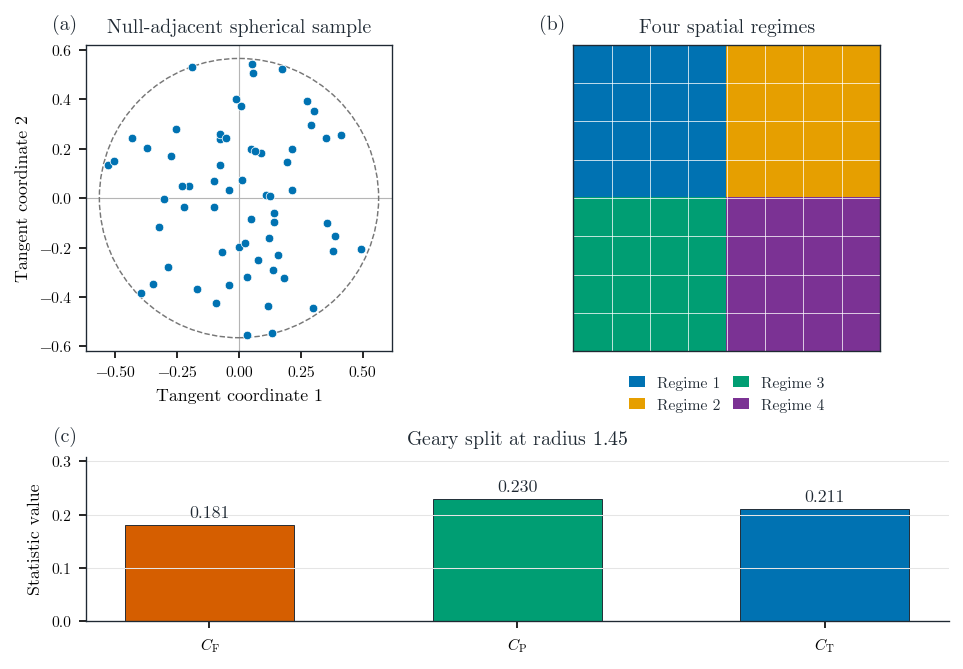

In [3]:
figure = plt.figure(figsize=(ac.TEXT_WIDTH_IN, 4.8), constrained_layout=False)
grid = figure.add_gridspec(
    2, 2, left=0.10, right=0.985, bottom=0.11, top=0.91,
    height_ratios=[1.50, 0.80], wspace=0.30, hspace=0.45,
)
ax_a = figure.add_subplot(grid[0, 0])
ax_b = figure.add_subplot(grid[0, 1])
ax_c = figure.add_subplot(grid[1, :])

ax_a.axhline(0, color="#B5B5B5", linewidth=0.55, zorder=0)
ax_a.axvline(0, color="#B5B5B5", linewidth=0.55, zorder=0)
ax_a.add_patch(plt.Circle((0, 0), np.sin(0.60), fill=False,
                          color="#777777", linestyle="--", linewidth=0.7))
ax_a.scatter(null_sample[:, 0], null_sample[:, 1], s=17, c=ac.BLUE,
             edgecolors="white", linewidths=0.35)
ax_a.set(title="Null-adjacent spherical sample", xlabel="Tangent coordinate 1",
         ylabel="Tangent coordinate 2", xlim=(-0.62, 0.62), ylim=(-0.62, 0.62))
ax_a.set_aspect("equal")
ax_a.set_anchor("W")
ac.panel_label(ax_a, "a")

regime_colors = ListedColormap([ac.BLUE, ac.GOLD, ac.GREEN, ac.PURPLE])
ax_b.imshow(regimes, interpolation="nearest", cmap=regime_colors, vmin=-0.5, vmax=3.5)
ax_b.set_xticks(np.arange(-0.5, 8, 1), minor=True)
ax_b.set_yticks(np.arange(-0.5, 8, 1), minor=True)
ax_b.grid(which="minor", color="white", linewidth=0.45, alpha=0.78)
ax_b.tick_params(which="both", bottom=False, left=False, labelbottom=False, labelleft=False)
ax_b.set_title("Four spatial regimes")
ax_b.legend(
    handles=[Patch(facecolor=regime_colors(i), edgecolor="none", label=f"Regime {i + 1}") for i in range(4)],
    loc="upper center", bbox_to_anchor=(0.5, -0.06), ncol=2,
    columnspacing=0.8, handlelength=1.0, borderaxespad=0.0,
)
ax_b.set_anchor("W")
ac.panel_label(ax_b, "b")

values = [high_result.C_F, high_result.C_P, high_result.C_T]
bars = ax_c.bar([r"$C_{\mathrm{F}}$", r"$C_{\mathrm{P}}$", r"$C_{\mathrm{T}}$"],
                values, color=[ac.ORANGE, ac.GREEN, ac.BLUE],
                edgecolor=ac.INK, linewidth=0.45, width=0.55)
ax_c.set(title=r"Geary split at radius $1.45$", ylabel="Statistic value",
         ylim=(0, max(values) * 1.34))
ax_c.spines[["top", "right"]].set_visible(False)
ax_c.grid(axis="y", color="#E5E5E5", linewidth=0.5)
for bar, value in zip(bars, values):
    ax_c.text(bar.get_x() + bar.get_width() / 2, value + 0.008,
              f"{value:.3f}", ha="center", va="bottom")
ac.panel_label(ax_c, "c")
plt.show()

**Figure 1.** Panel (a) shows the weakly dispersed spherical sample.
Panel (b) shows the four spatial regimes; its legend is separated from
the heatmap without changing the top-row alignment. Panel (c) compares
the Fréchet, pairwise, and tangent Geary values.

In [4]:
archived = pd.DataFrame(paper["controlled_spherical_behavior"]["cases"])
archived["case"] = ["Null-adjacent random field", "Four spatial regimes"]
comparison = fresh[["case", "I", "C_F", "C_P", "C_T"]].merge(
    archived[["case", "I", "C_F", "C_P", "C_T"]],
    on="case", suffixes=("_fresh", "_paper"),
)
display(comparison.round(6))

bridge = (63 / 64) * (1 + high_result.L - high_result.I)
print(f"Tangent bridge error: {abs(high_result.C_T - bridge):.3e}")
print(f"Geary factorization error: {abs(high_result.C_F - high_result.kappa * high_result.C_P):.3e}")

,case,I_fresh,C_F_fresh,C_P_fresh,C_T_fresh,I_paper,C_F_paper,C_P_paper,C_T_paper
0,Null-adjacent random field,0.010105,0.980700,0.992570,0.992849,0.010105,0.980700,0.992570,0.992849
1,Four spatial regimes,0.785714,0.181124,0.229855,0.210938,0.785714,0.181124,0.229855,0.210937


Tangent bridge error: 8.327e-17
Geary factorization error: 0.000e+00


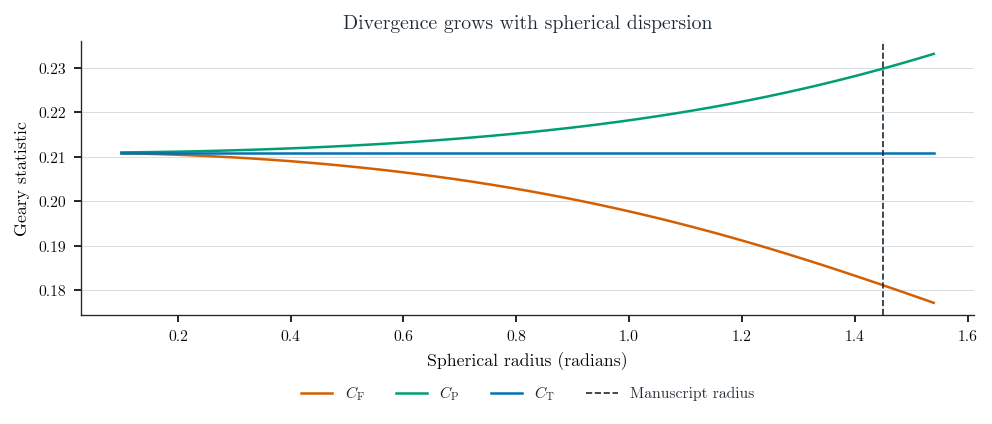

In [5]:
radii = np.linspace(0.10, 1.54, 45)
curves = []
for current_radius in radii:
    sample = np.vstack([
        ac.sphere_exp(north, current_radius * directions[group])
        for group in regimes.ravel()
    ])
    _, logarithms, distance_squared, dispersion = ac.sphere_components(sample)
    values = ac.global_measures(logarithms, distance_squared, W, V_mu=dispersion)
    curves.append(values)
curves = pd.DataFrame(curves)

fig, ax = plt.subplots(figsize=(ac.TEXT_WIDTH_IN, 2.7), constrained_layout=True)
ax.plot(radii, curves["C_F"], label=r"$C_{\mathrm{F}}$", color=ac.ORANGE)
ax.plot(radii, curves["C_P"], label=r"$C_{\mathrm{P}}$", color=ac.GREEN)
ax.plot(radii, curves["C_T"], label=r"$C_{\mathrm{T}}$", color=ac.BLUE)
ax.axvline(1.45, color=ac.INK, linestyle="--", linewidth=0.8, label="Manuscript radius")
ax.set(xlabel="Spherical radius (radians)", ylabel="Geary statistic",
       title="Divergence grows with spherical dispersion")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color=ac.GRID, linewidth=0.5)
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.20))
plt.show()

**Figure 2.** The three constructions nearly coincide for small
spherical radii and separate as the regimes approach the edge of the
admissible hemisphere. The dashed line marks the controlled case used
in the manuscript.